# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [1]:
# Tratamiento de datos
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [2]:
df = pd.read_csv("data/comprar_alquilar.csv")
df.head(5)

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB


In [4]:
print(df.columns)
print(df.shape[1])

Index(['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros',
       'vivienda', 'estado_civil', 'hijos', 'trabajo', 'comprar'],
      dtype='object')
10


### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

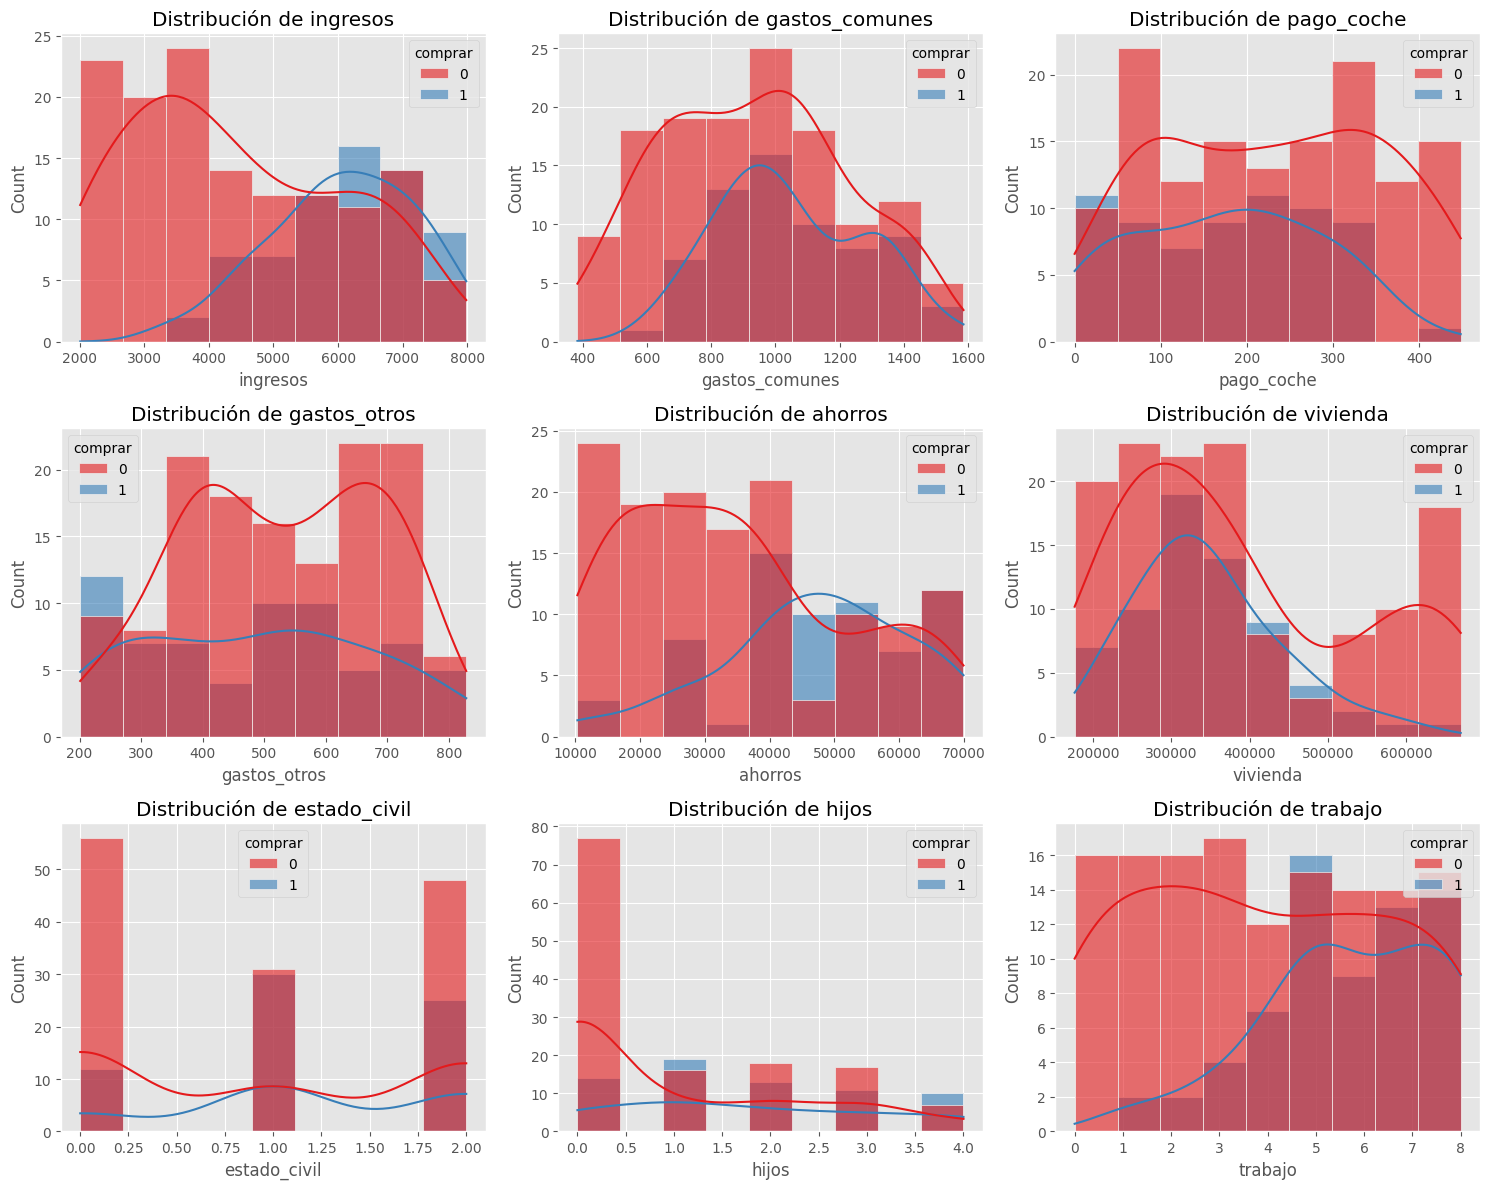

In [5]:
# análisis univariante con histogramas diferenciados por el target 'comprar'

variables = df.drop(columns=['comprar']).columns
n_cols = 3
n_rows = int(np.ceil(len(variables) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.histplot(data=df,
                 x=var,
                 hue='comprar',
                 kde=True,
                 palette='Set1',
                 ax=axes[i],
                 alpha=0.6)
    axes[i].set_title(f"Distribución de {var}")

# elimino ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [6]:
# Análisis univariante de las variables del dataset.

# En esta sección se estudia la distribución de cada variable numérica,
# diferenciando por el target 'comprar' (0 = alquilar, 1 = comprar)
#
# A partir de las gráficas se observan patrones relevantes:
#
# - ingresos: los compradores presentan ingresos más altos; clara separación entre clases
# - gastos_comunes: distribuciones similares; variable poco discriminativa
# - pago_coche: los compradores muestran pagos de coche más elevados
# - gastos_otros: ligera tendencia a valores más altos en compradores
# - ahorros: una de las variables más diferenciadoras; los compradores tienen muchos más ahorros
# - vivienda: valores más altos en compradores; indica mayor patrimonio
# - estado_civil: ciertos estados civiles aparecen más asociados a la compra
# - hijos: los compradores tienden a tener más hijos; relación con tamaño del hogar
# - trabajo: valores más altos en compradores; sugiere mejor posición laboral
#
# En conjunto, las variables con mayor capacidad de separación entre clases son:
# ingresos, ahorros, vivienda, trabajo e hijos
# Estas serán especialmente relevantes en el PCA y en modelos posteriores


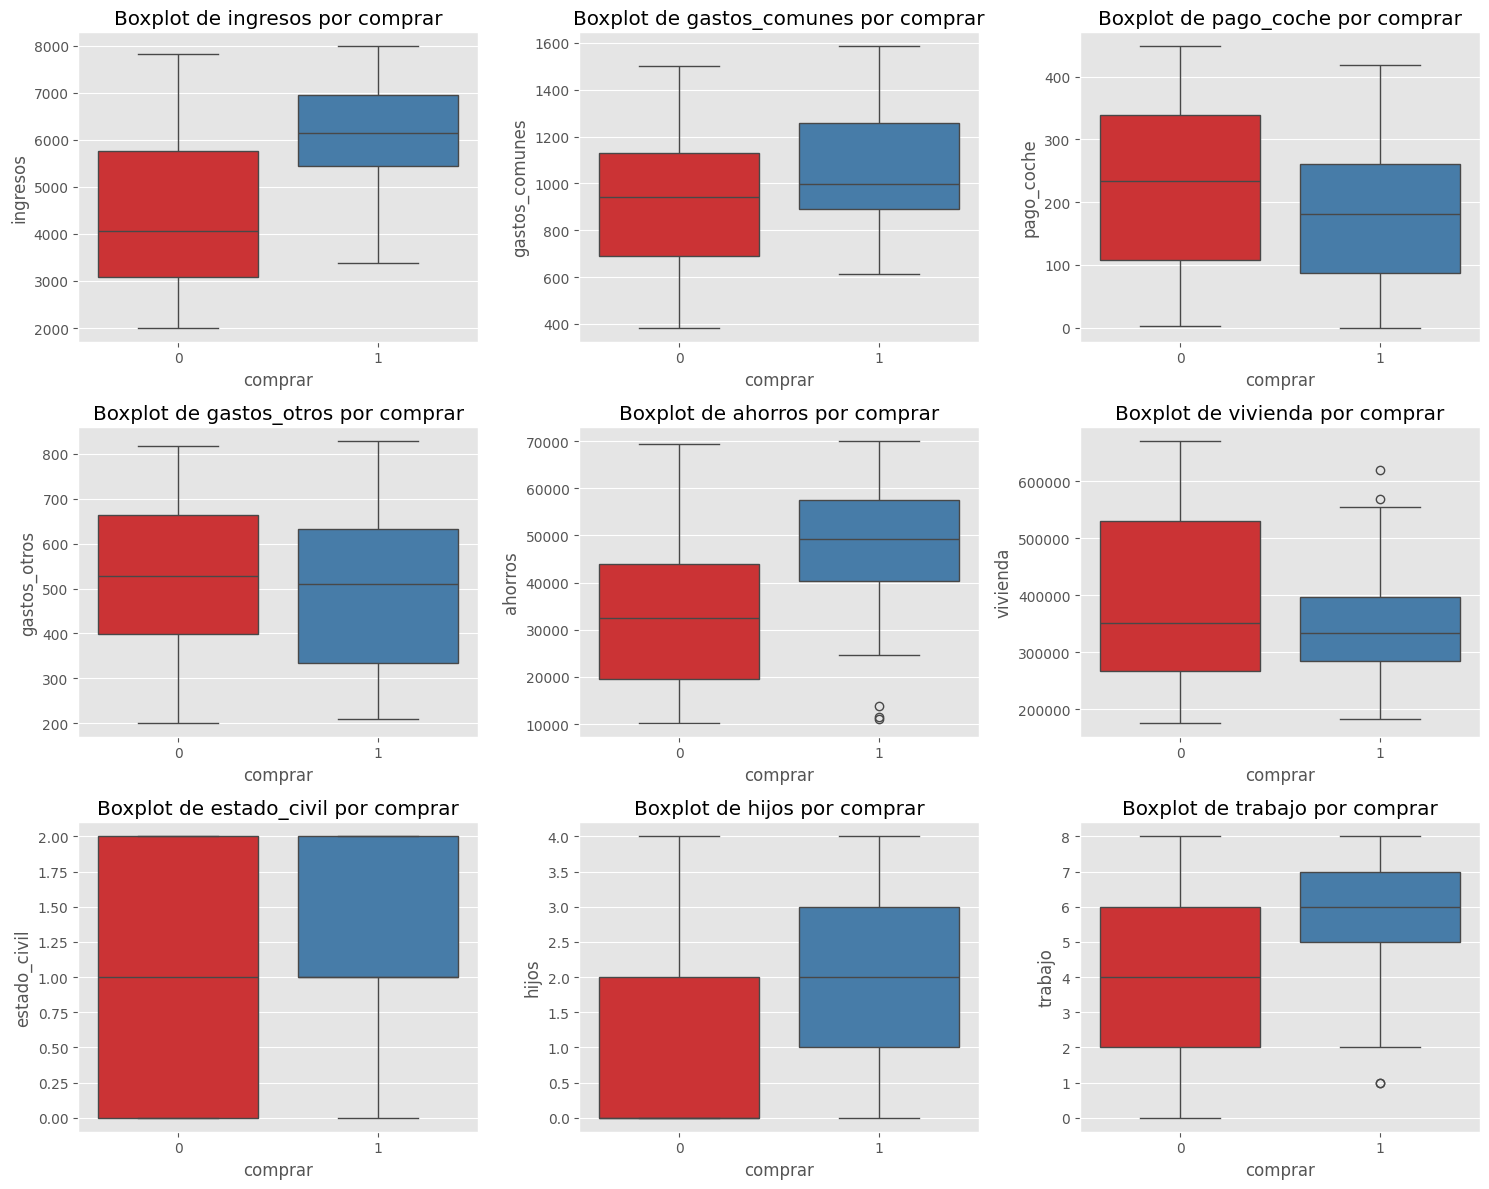

In [7]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.boxplot(data=df,
                x='comprar',
                y=var,
                palette='Set1',
                ax=axes[i])
    axes[i].set_title(f"Boxplot de {var} por comprar")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

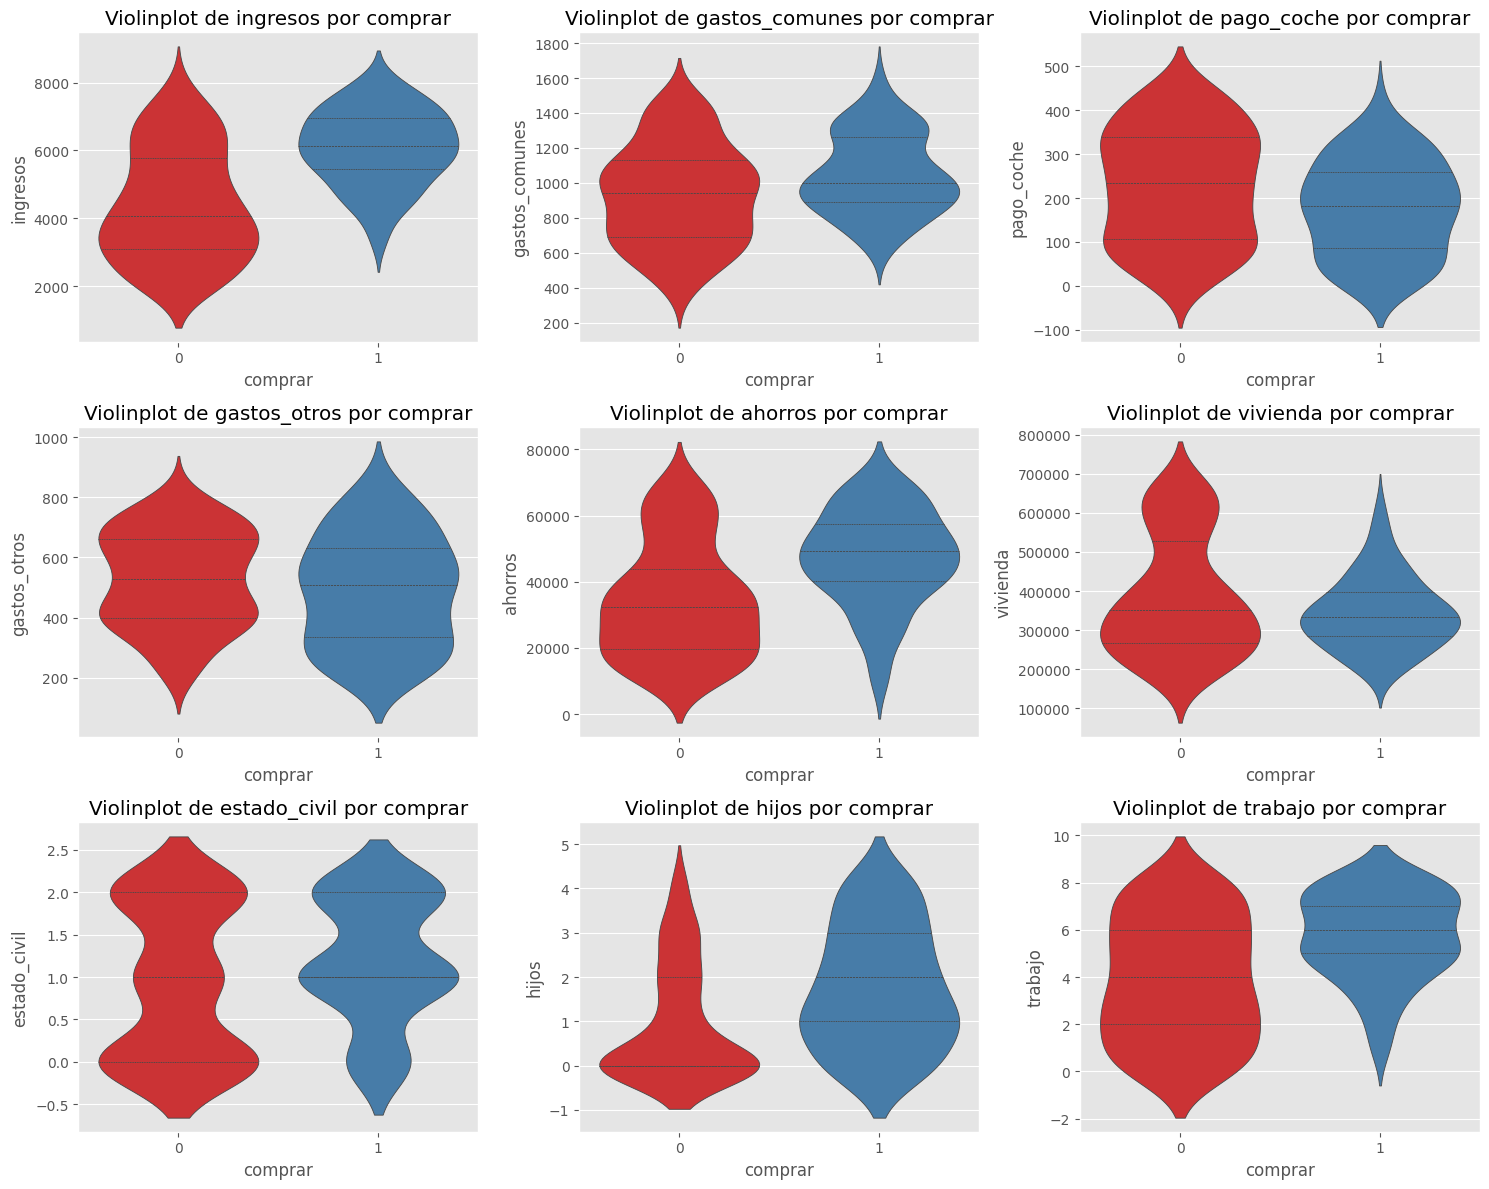

In [8]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.violinplot(data=df,
                    x='comprar',
                    y=var,
                    palette='Set1',
                    ax=axes[i],
                    inner='quartile')
    axes[i].set_title(f"Violinplot de {var} por comprar")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [9]:
# estandarizo todas las variables predictoras para que tengan media 0 y desviación típica 1
# imprescindible antes de aplicar PCA, para evitar que verables mayoresdominen la varianza
# frente a otras de menor magnitud.
# no hago train/test split porque el objetivo es únicamente analizar la estructura de los datos
# y no optimizar un modelo predictivo

X = df.drop(columns=['comprar']) # variables explicativas
y = df['comprar'] # target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [10]:
# aplico P CA con 9 componentes (todas las features)

pca = PCA(n_components=9)
pca.fit(X_scaled)

pca.explained_variance_ratio_ # varianza explicada por cada componente


array([0.29913557, 0.23294923, 0.11711241, 0.10685622, 0.09635279,
       0.05629866, 0.04145579, 0.03017819, 0.01966115])

In [11]:
# voy a ver la transformación
X_pca = pca.transform(X_scaled)
X_pca[:5]

array([[ 1.32191526, -0.22295045,  1.59986259, -0.88501437,  0.64661707,
        -0.70020777,  0.31803061, -0.75180934,  0.26998397],
       [ 1.14787775,  1.7169673 ,  0.39572194, -0.44795996, -0.68780535,
        -0.23196889,  1.54248744,  0.22179854,  0.43842516],
       [ 0.09036864,  1.83606627,  1.35938166,  0.33750498,  0.74238673,
         0.59302961, -1.54049502,  0.66811958,  0.15346276],
       [ 3.4558983 , -0.07827948, -0.20238186, -1.57358379, -0.06855138,
        -0.05194502,  0.90940913,  0.68448572, -0.12904521],
       [ 0.91693305, -1.18467627,  0.19003578,  0.1178037 , -0.14775256,
        -0.61974977, -0.45041862,  0.19434149,  0.68745216]])

In [12]:
# lo convierto en df
df_pca = pd.DataFrame(X_pca,
                      columns=[f"PC{i+1}" for i in range(9)])

df_pca.head(5)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1.321915,-0.222950,1.599863,-0.885014,0.646617,-0.700208,0.318031,-0.751809,0.269984
1,1.147878,1.716967,0.395722,-0.447960,-0.687805,-0.231969,1.542487,0.221799,0.438425
2,0.090369,1.836066,1.359382,0.337505,0.742387,0.593030,-1.540495,0.668120,0.153463
3,3.455898,-0.078279,-0.202382,-1.573584,-0.068551,-0.051945,0.909409,0.684486,-0.129045
4,0.916933,-1.184676,0.190036,0.117804,-0.147753,-0.619750,-0.450419,0.194341,0.687452


### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?
2. ¿Y de manera acumulada empezando por el PC1?
3. ¿Cuánta varianza explicarían sólo 5 componentes?

In [13]:
# 1: varianza explicada por cada componente

varianza = pca.explained_variance_ratio_
varianza

array([0.29913557, 0.23294923, 0.11711241, 0.10685622, 0.09635279,
       0.05629866, 0.04145579, 0.03017819, 0.01966115])

In [14]:
# 2: varianza explicada acumulada
var_acum = pca.explained_variance_ratio_.cumsum()
var_acum

array([0.29913557, 0.5320848 , 0.64919721, 0.75605343, 0.85240621,
       0.90870487, 0.95016066, 0.98033885, 1.        ])

In [15]:
# 3: varianza explicada por los primeros 5 componentes
var_5 = var_acum[4] # índice 4 = PC5
var_5


np.float64(0.8524062117714313)

In [16]:
# interpretación del PCA

# 1: la varianza explicada por cada componente (pca.explained_variance_ratio_)
# indica cuánta información aporta cada PC respecto a las variables originales
#
# 2: la varianza explicada acumulada muestra cómo se va sumando la información
# a medida que añadimos componentes: PC1, luego PC1+PC2, etc
#
# 3: la varianza explicada por los primeros 5 componentes (var_acum[4])
# indica qué porcentaje de la estructura total del dataset puede
# representarse usando solo 5 dimensiones en lugar de las 9 originales
#
# esto es clave para decidir cuántos PCs conservar en un modelo reducido


### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

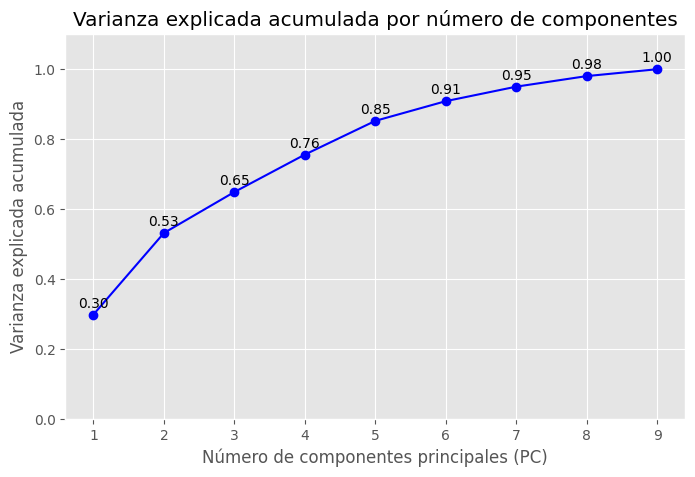

In [17]:
# variación explicada acumulada

var_acum = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_acum)+1), var_acum, marker='o', linestyle='-', color='blue')

# etiquetas de cada punto
for i, v in enumerate(var_acum):
    plt.text(i+1, v + 0.02, f"{v:.2f}", ha='center')

plt.title("Varianza explicada acumulada por número de componentes")
plt.xlabel("Número de componentes principales (PC)")
plt.ylabel("Varianza explicada acumulada")
plt.xticks(range(1, len(var_acum)+1))
plt.ylim(0, 1.1)
plt.grid(True)

plt.show()


In [18]:
# Interpretación de la varianza explicada acumulada

# la gráfica muestra cómo aumenta la varianza total explicada a medida que se
# añaden componentes principales (PC). Esto permite evaluar cuántas dimensiones
# son necesarias para representar adecuadamente la información del dataset
#
# Los valores observados son aproximadamente:
# PC1 → 0.30
# PC2 → 0.53
# PC3 → 0.65
# PC4 → 0.76
# PC5 → 0.85
# PC6 → 0.91
# PC7 → 0.95
# PC8 → 0.98
# PC9 → 1.00
#
# Conclusiones:
# - PC1 explica alrededor del 30% de la varianza: aporta bastante información,
#   pero no es suficiente por sí solo.
# - Con 2–3 componentes se supera el 50–65%, lo que indica correlación entre
#   variables originales.
# - Con 4 componentes se alcanza ~76%, un umbral razonable para reducción
#   dimensional sin gran pérdida de información.
# - Con 5 componentes se explica ~85%, lo que supone una representación muy
#   eficiente del dataset.
# - A partir de PC6 la ganancia es marginal: las últimas componentes aportan
#   muy poca varianza adicional y contienen sobre todo ruido.
#
# En conjunto, el dataset podría reducirse de 9 variables originales a 4–5 PCs
# manteniendo la mayor parte de la estructura y variabilidad relevante.


### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

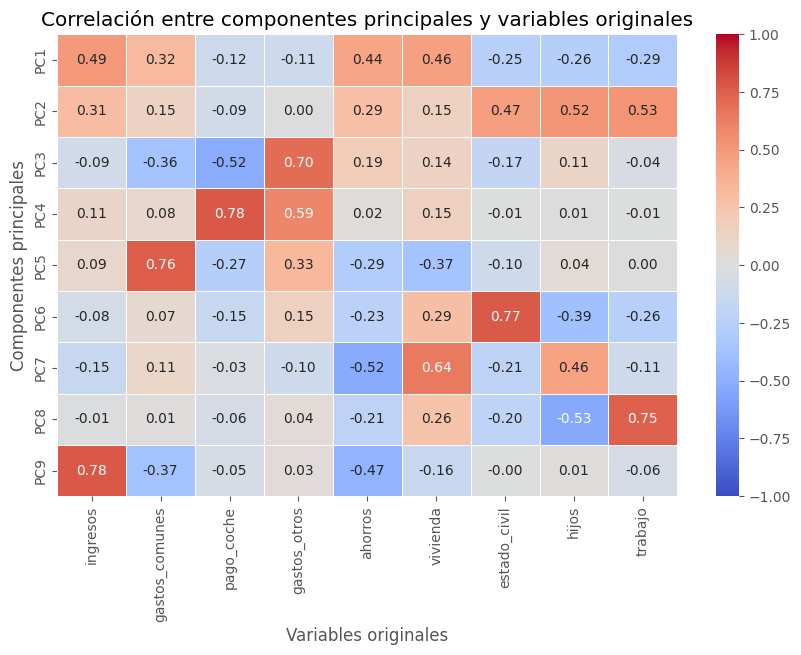

In [19]:
# mapa de calor de correlación entre PCs y variables originales

# creo un df con las cargas (loadings) del PCA
loadings = pd.DataFrame(pca.components_,
                        columns=X.columns,
                        index=[f"PC{i+1}" for i in range(pca.n_components_)])

plt.figure(figsize=(10,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", fmt=".2f",linewidths=0.5,vmin=-1,vmax=1)
plt.title("Correlación entre componentes principales y variables originales")
plt.xlabel("Variables originales")
plt.ylabel("Componentes principales")
plt.show()


In [20]:
# Interpretación del mapa de calor PCA vs variables originales
# ------------------------------------------------------------
# El mapa de calor muestra las cargas (loadings) de cada variable original
# en cada componente principal. Los valores indican cuánto contribuye cada
# variable a la formación de cada PC:
#   - Valores altos positivos → la variable aporta fuertemente en esa dirección.
#   - Valores altos negativos → la variable aporta en sentido contrario.
#   - Valores cercanos a 0 → poca influencia en ese componente.
#
# Principales observaciones:
#
# • PC1: está fuertemente influido por ingresos, ahorros, vivienda y trabajo.
#   Representa claramente un eje de "capacidad económica / estabilidad financiera".
#
# • PC2: carga principalmente en gastos_comunes y gastos_otros, capturando un
#   patrón relacionado con los gastos recurrentes del ciudadano.
#
# • PC3: muestra peso relevante en pago_coche y estado_civil, indicando un
#   componente más asociado a estructura familiar y compromisos financieros.
#
# • PC4 y PC5: combinan información de hijos, estado_civil y trabajo, reflejando
#   variabilidad más específica del perfil personal y laboral.
#
# • PCs posteriores (PC6–PC9): presentan cargas pequeñas y dispersas, lo que
#   indica que capturan variabilidad residual o ruido.
#
# En conjunto, los primeros componentes (PC1–PC3) concentran las relaciones
# más fuertes entre variables y explican la mayor parte de la estructura del
# dataset, mientras que los últimos PCs aportan información marginal.


## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo